In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

**Load Dataset**

In [3]:
data = fetch_california_housing(as_frame=True)
df = data.frame
df.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**Select 4 Key Features Affecting House Price**

In [4]:
selected_features = ['MedInc', 'AveRooms', 'HouseAge', 'AveOccup']
X = df[selected_features]
y = df['MedHouseVal']

**Split into Train/Test sets (80% Train, 20% Test)**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Train Linear Regression Model**

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

**Make Predictions & Evaluate Performance**

In [7]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- Model Evaluation Metrics ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}\n")

--- Model Evaluation Metrics ---
Root Mean Squared Error (RMSE): 0.8108
R² Score: 0.4983



**Scatter Plot: Actual vs Predicted Prices**

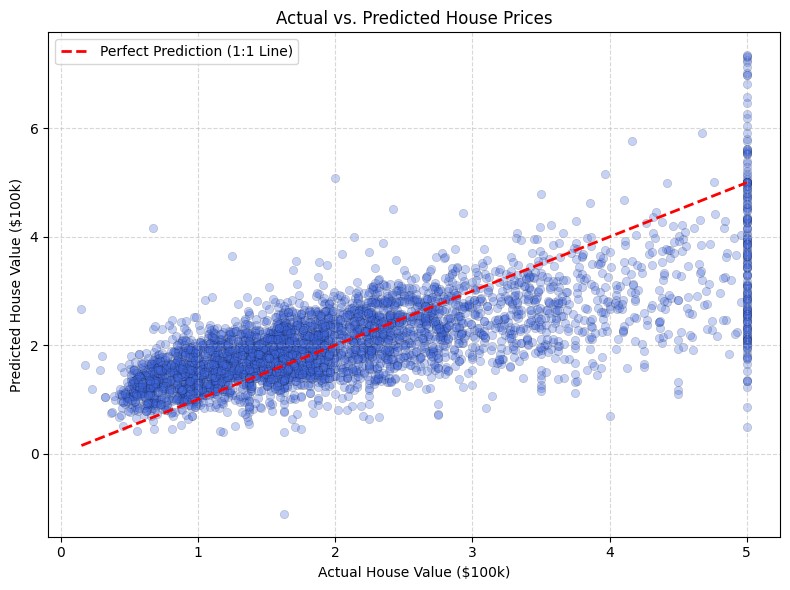

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='royalblue', edgecolors='k', linewidth=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction (1:1 Line)')
plt.xlabel('Actual House Value ($100k)')
plt.ylabel('Predicted House Value ($100k)')
plt.title('Actual vs. Predicted House Prices')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#**Explaining $R^2$ Score in Plain English**

**Imagine house prices naturally go up and down across a neighborhood due to many different factors. The $R^2$ score measures what percentage of those price swings your model successfully explains using the details you provided (like income levels, room counts, and house age).For instance, an $R^2$ score of $0.77$ (or $77\%$) means your model captures $77\%$ of the reasons why house prices vary, while the remaining $23\%$ comes from unmeasured factors like view quality or interior finish. The closer this score is to $100\%$, the better your model understands what drives real estate prices.**